# 1. Data Exploration

Loads the raw UMA Adabyron telemetry, resamples it into the 15-minute feature set used by the forecasters, and looks at what the PV generation and EV demand signals actually look like before any modeling happens.

The raw dataset is private (available on request) and is not included in this repository; this notebook expects it at `../data/20260514_uma_adabyron_data.csv`, or you can point `DATA_PATH` below at your own copy.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import matplotlib.pyplot as plt
import pandas as pd

from evloadshaping.data import load_raw_data
from evloadshaping.features import build_features

DATA_PATH = Path('../data/20260514_uma_adabyron_data.csv')
pd.set_option('display.max_columns', 20)

## Load the raw telemetry

The loader only reads the columns the pipeline needs, so this is fast even though the source CSV is hundreds of megabytes.

In [2]:
raw_frame, charger_ids = load_raw_data(DATA_PATH)
print(f'Detected EV chargers: {charger_ids}')
print(f'Raw rows: {len(raw_frame):,}')
print(f'Time range: {raw_frame.index.min()} to {raw_frame.index.max()}')
raw_frame.head()

Detected EV chargers: [1, 2, 3, 4, 5]
Raw rows: 3,232,936
Time range: 2023-07-11 10:00:00 to 2026-05-14 10:45:03


,uma_adabyron_solarpanels_pvGeneration,uma_adabyron_weatherStation_relativeHumidity,uma_adabyron_weatherStation_solarRadiation,uma_adabyron_weatherStation_temperature,uma_adabyron_weatherStation_windSpeed,uma_adabyron_EVCharger-1_vehicle_connected,uma_adabyron_EVCharger-2_vehicle_connected,uma_adabyron_EVCharger-3_vehicle_connected,uma_adabyron_EVCharger-4_vehicle_connected,uma_adabyron_EVCharger-5_vehicle_connected,uma_adabyron_EVCharger-1_real_power_sum,uma_adabyron_EVCharger-2_real_power_sum,uma_adabyron_EVCharger-3_real_power_sum,uma_adabyron_EVCharger-4_real_power_sum,uma_adabyron_EVCharger-5_real_power_sum
_time,,,,,,,,,,,,,,,
2023-07-11 10:00:00.000,NaN,44.0,2.0,32.3,3.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-07-11 11:00:00.000,NaN,53.0,3.0,30.7,7.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-07-11 11:10:40.277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-07-11 11:13:43.476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-07-11 11:15:40.272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Resample into the 15-minute feature set

This aggregates the per-charger power/connection columns into site totals, resamples to 15-minute intervals, and adds the cyclical time and lag/rolling features described in the paper.

In [3]:
feature_frame = build_features(raw_frame, charger_ids)
print(f'Feature rows after resampling + dropna: {len(feature_frame):,}')
feature_frame[[
    'uma_adabyron_solarpanels_pvGeneration',
    'total_ev_power_demand',
    'total_evs_connected',
]].describe()

Feature rows after resampling + dropna: 57,681


,uma_adabyron_solarpanels_pvGeneration,total_ev_power_demand,total_evs_connected
count,57681.000000,57681.000000,57681.000000
mean,3292.570335,123.895112,0.246008
std,3978.457196,617.627634,0.676804
min,0.000000,0.000000,0.000000
25%,26.714285,0.000000,0.000000
50%,515.083300,0.000000,0.000000
75%,7717.916500,0.000000,0.000000
max,16445.637000,22167.040527,5.000000


## PV generation and EV demand over a sample window

A two-week slice is easier to read than the full 2.8-year span; the diurnal PV cycle and the much spikier EV demand are both visible here.

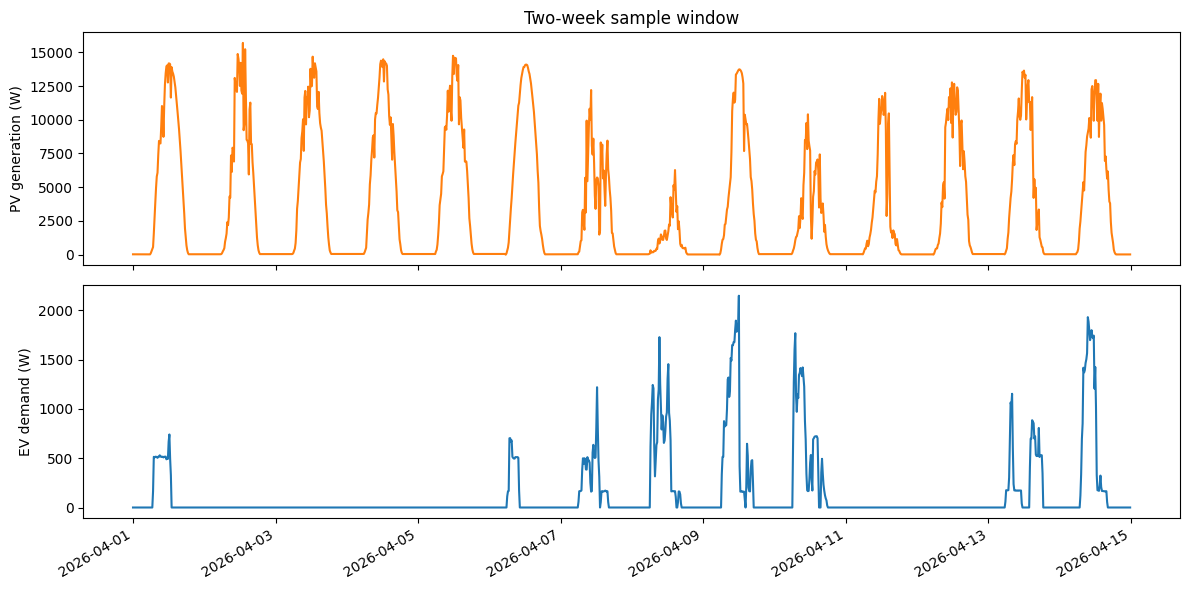

In [4]:
window = feature_frame.loc['2026-04-01':'2026-04-14']

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(window.index, window['uma_adabyron_solarpanels_pvGeneration'], color='tab:orange')
axes[0].set_ylabel('PV generation (W)')
axes[0].set_title('Two-week sample window')

axes[1].plot(window.index, window['total_ev_power_demand'], color='tab:blue')
axes[1].set_ylabel('EV demand (W)')
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## How the two targets relate to weather and time

A quick correlation check against the *current-timestep* signals motivates the feature set: PV tracks solar radiation and hour-of-day tightly, while EV demand is far less predictable from weather alone.

In [5]:
corr_columns = [
    'uma_adabyron_solarpanels_pvGeneration',
    'total_ev_power_demand',
    'uma_adabyron_weatherStation_solarRadiation',
    'uma_adabyron_weatherStation_temperature',
    'hour_sin',
    'hour_cos',
]
feature_frame[corr_columns].corr().round(2)

,uma_adabyron_solarpanels_pvGeneration,total_ev_power_demand,uma_adabyron_weatherStation_solarRadiation,uma_adabyron_weatherStation_temperature,hour_sin,hour_cos
uma_adabyron_solarpanels_pvGeneration,1.00,0.13,0.44,0.33,0.03,-0.62
total_ev_power_demand,0.13,1.00,0.06,-0.06,0.14,-0.18
uma_adabyron_weatherStation_solarRadiation,0.44,0.06,1.00,0.50,-0.03,-0.46
uma_adabyron_weatherStation_temperature,0.33,-0.06,0.50,1.00,-0.14,-0.16
hour_sin,0.03,0.14,-0.03,-0.14,1.00,-0.00
hour_cos,-0.62,-0.18,-0.46,-0.16,-0.00,1.00
